## Import packages

In [1]:
import sys
sys.path.append('..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import prepare_data, create_sequences
from src import build_lstm_model
from src import train_model, evaluate_model

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})

## Load data and config

In [2]:
df = pd.read_csv('../data/raw/featured_data.csv', index_col=0, parse_dates=True)

with open('../data/raw/selected_features.json', 'r') as f:
    selected_features = json.load(f)

ticker = "AAPL"
print(f"Loaded data: {df.shape}")
print(f"Features: {selected_features}")

Loaded data: (1207, 37)
Features: ['Close', 'Volume_SMA_20', 'Volume', 'MACD_Signal']


## Baseline model performance

In [3]:
with open('../models/training_config.json', 'r') as f:
    baseline_config = json.load(f)

print("BASELINE PERFORMANCE:")
print(f"  RMSE: ${baseline_config['rmse']:.2f}")
print(f"  MAE: ${baseline_config['mae']:.2f}")
print(f"  Epochs: {baseline_config['epochs']}")
print(f"  Sequence length: {baseline_config['seq_length']}")

BASELINE PERFORMANCE:
  RMSE: $6.89
  MAE: $5.38
  Epochs: 50
  Sequence length: 60


## Helper function for experiments

In [4]:
def run_experiment(df, features, seq_length, units, dropout, epochs, batch_size, test_size=0.2):
    """Run a single training experiment and return results."""
    train_data, test_data, scaler = prepare_data(df, feature_columns=features, test_size=test_size)
    X_train, y_train = create_sequences(train_data, seq_length=seq_length)
    X_test, y_test = create_sequences(test_data, seq_length=seq_length)

    if len(X_test) == 0 or len(X_train) == 0:
        print(f"  Skipped: not enough data for seq_length={seq_length}")
        return None

    n_features = X_train.shape[2]
    model = build_lstm_model(seq_length=seq_length, n_features=n_features, units=units, dropout=dropout)

    history = train_model(model, X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)
    results = evaluate_model(model, X_test, y_test, scaler)

    return {
        "model": model,
        "history": history,
        "results": results,
        "scaler": scaler,
        "rmse": results['rmse'],
        "mae": results['mae'],
        "config": {
            "seq_length": seq_length,
            "units": units,
            "dropout": dropout,
            "epochs": epochs,
            "batch_size": batch_size
        }
    }

## Experiment 1 - Sequence length tuning

In [5]:
print("EXPERIMENT 1: Sequence Length")
print("=" * 40)

seq_lengths = [20, 30, 40, 60]
seq_results = []

for sl in seq_lengths:
    print(f"\nTesting seq_length={sl}...")
    result = run_experiment(df, selected_features, seq_length=sl, units=50, dropout=0.2, epochs=30, batch_size=32)
    if result:
        seq_results.append({"seq_length": sl, "rmse": result['rmse'], "mae": result['mae']})
        print(f"  RMSE: ${result['rmse']:.2f}, MAE: ${result['mae']:.2f}")

seq_df = pd.DataFrame(seq_results)
print(f"\nBest sequence length: {seq_df.loc[seq_df['rmse'].idxmin(), 'seq_length']}")

  RMSE: $8.68, MAE: $6.89

Best sequence length: 60


## Plot sequence length results

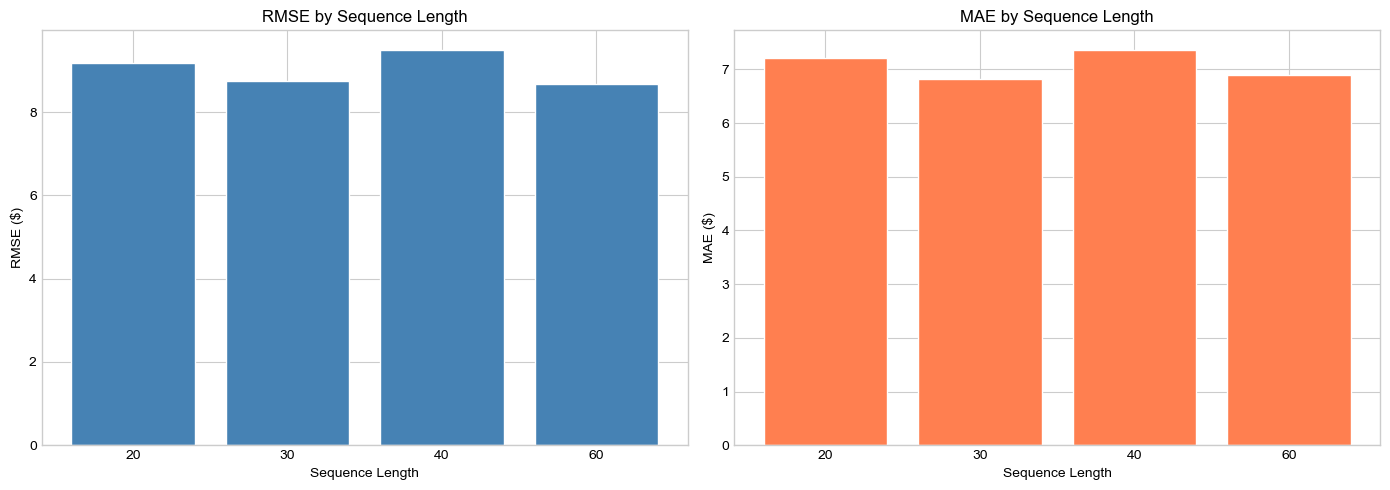

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(s) for s in seq_df['seq_length']], seq_df['rmse'], color='steelblue')
axes[0].set_title('RMSE by Sequence Length')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('RMSE ($)')

axes[1].bar([str(s) for s in seq_df['seq_length']], seq_df['mae'], color='coral')
axes[1].set_title('MAE by Sequence Length')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('MAE ($)')

plt.tight_layout()
plt.show()

## Experiment 2 - LSTM units tuning

In [7]:
print("EXPERIMENT 2: LSTM Units")
print("=" * 40)

best_seq = int(seq_df.loc[seq_df['rmse'].idxmin(), 'seq_length'])
unit_options = [32, 50, 64, 100]
unit_results = []

for u in unit_options:
    print(f"\nTesting units={u}...")
    result = run_experiment(df, selected_features, seq_length=best_seq, units=u, dropout=0.2, epochs=30, batch_size=32)
    unit_results.append({"units": u, "rmse": result['rmse'], "mae": result['mae']})
    print(f"  RMSE: ${result['rmse']:.2f}, MAE: ${result['mae']:.2f}")

unit_df = pd.DataFrame(unit_results)
print(f"\nBest units: {unit_df.loc[unit_df['rmse'].idxmin(), 'units']}")

  RMSE: $8.02, MAE: $6.52

Best units: 64


## Plot units results

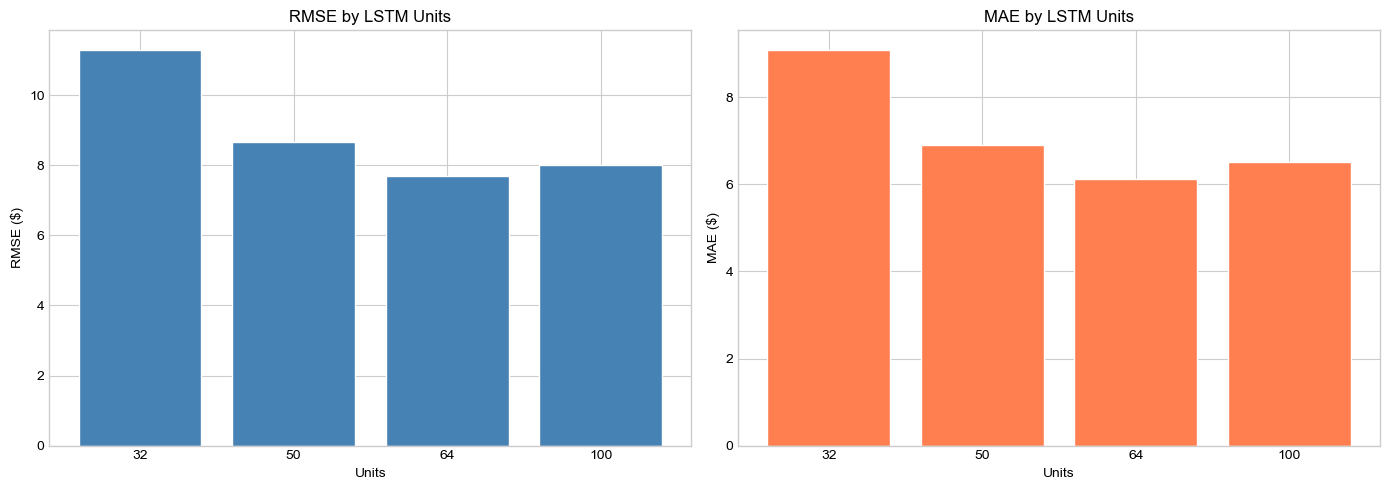

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(u) for u in unit_df['units']], unit_df['rmse'], color='steelblue')
axes[0].set_title('RMSE by LSTM Units')
axes[0].set_xlabel('Units')
axes[0].set_ylabel('RMSE ($)')

axes[1].bar([str(u) for u in unit_df['units']], unit_df['mae'], color='coral')
axes[1].set_title('MAE by LSTM Units')
axes[1].set_xlabel('Units')
axes[1].set_ylabel('MAE ($)')

plt.tight_layout()
plt.show()

## Experiment 3 - Dropout tuning

In [9]:
print("EXPERIMENT 3: Dropout Rate")
print("=" * 40)

best_units = int(unit_df.loc[unit_df['rmse'].idxmin(), 'units'])
dropout_options = [0.1, 0.2, 0.3, 0.4]
dropout_results = []

for d in dropout_options:
    print(f"\nTesting dropout={d}...")
    result = run_experiment(df, selected_features, seq_length=best_seq, units=best_units, dropout=d, epochs=30, batch_size=32)
    dropout_results.append({"dropout": d, "rmse": result['rmse'], "mae": result['mae']})
    print(f"  RMSE: ${result['rmse']:.2f}, MAE: ${result['mae']:.2f}")

dropout_df = pd.DataFrame(dropout_results)
print(f"\nBest dropout: {dropout_df.loc[dropout_df['rmse'].idxmin(), 'dropout']}")

  RMSE: $10.42, MAE: $8.30

Best dropout: 0.1


## Plot dropout results

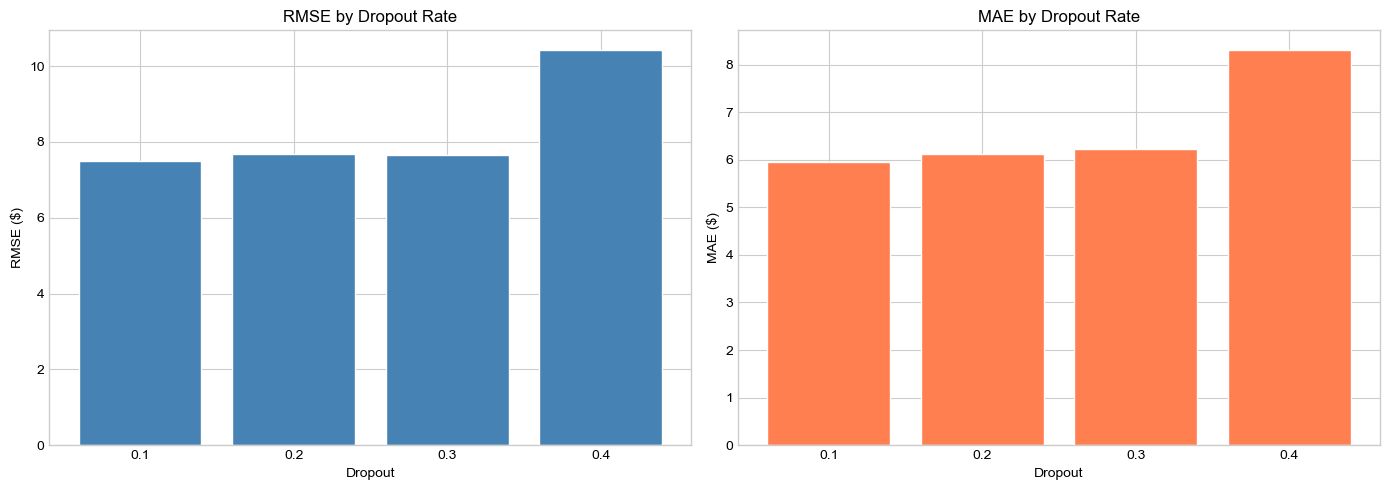

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(d) for d in dropout_df['dropout']], dropout_df['rmse'], color='steelblue')
axes[0].set_title('RMSE by Dropout Rate')
axes[0].set_xlabel('Dropout')
axes[0].set_ylabel('RMSE ($)')

axes[1].bar([str(d) for d in dropout_df['dropout']], dropout_df['mae'], color='coral')
axes[1].set_title('MAE by Dropout Rate')
axes[1].set_xlabel('Dropout')
axes[1].set_ylabel('MAE ($)')

plt.tight_layout()
plt.show()

## Experiment 4 - Batch size tuning

In [11]:

print("EXPERIMENT 4: Batch Size")
print("=" * 40)

best_dropout = float(dropout_df.loc[dropout_df['rmse'].idxmin(), 'dropout'])
batch_options = [16, 32, 64]
batch_results = []

for b in batch_options:
    print(f"\nTesting batch_size={b}...")
    result = run_experiment(df, selected_features, seq_length=best_seq, units=best_units, dropout=best_dropout, epochs=30, batch_size=b)
    batch_results.append({"batch_size": b, "rmse": result['rmse'], "mae": result['mae']})
    print(f"  RMSE: ${result['rmse']:.2f}, MAE: ${result['mae']:.2f}")

batch_df = pd.DataFrame(batch_results)
print(f"\nBest batch size: {batch_df.loc[batch_df['rmse'].idxmin(), 'batch_size']}")

  RMSE: $9.03, MAE: $7.21

Best batch size: 32


## Train final tuned model

In [12]:

best_batch = int(batch_df.loc[batch_df['rmse'].idxmin(), 'batch_size'])

print("FINAL TUNED MODEL")
print("=" * 40)
print(f"Sequence length: {best_seq}")
print(f"LSTM units: {best_units}")
print(f"Dropout: {best_dropout}")
print(f"Batch size: {best_batch}")
print(f"Epochs: 50")
print()

final = run_experiment(
    df, selected_features,
    seq_length=best_seq,
    units=best_units,
    dropout=best_dropout,
    epochs=50,
    batch_size=best_batch
)

print(f"\nFinal RMSE: ${final['rmse']:.2f}")
print(f"Final MAE: ${final['mae']:.2f}")


Final RMSE: $7.31
Final MAE: $5.81


## Plot final model training history

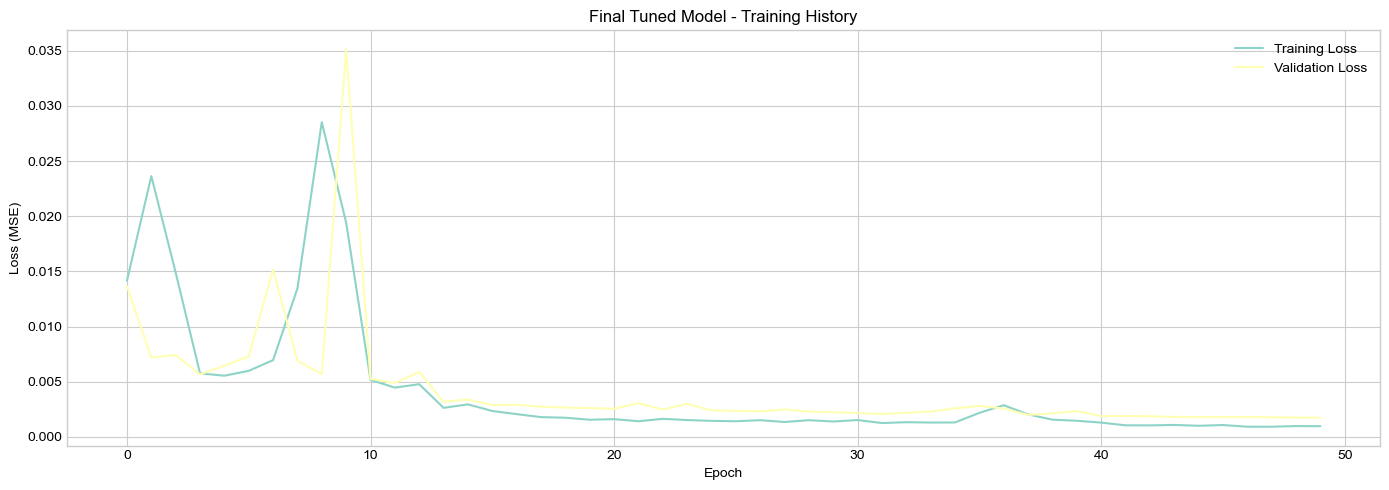

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(final['history'].history['loss'], label='Training Loss')
ax.plot(final['history'].history['val_loss'], label='Validation Loss')
ax.set_title('Final Tuned Model - Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.legend()
plt.tight_layout()
plt.show()

## Compare baseline vs tuned

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(final['results']['actual'], label='Actual Price', color='blue')
plt.plot(final['results']['predictions'], label='Tuned Predictions', color='red', alpha=0.7)
plt.title(f'{ticker} - Tuned Model: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nBASELINE vs TUNED:")
print(f"  Baseline RMSE: ${baseline_config['rmse']:.2f}")
print(f"  Tuned RMSE:    ${final['rmse']:.2f}")
print(f"  Improvement:   ${baseline_config['rmse'] - final['rmse']:.2f}")


BASELINE vs TUNED:
  Baseline RMSE: $6.89
  Tuned RMSE:    $7.31
  Improvement:   $-0.42


## Save tuned model and select best

In [15]:
import joblib
import shutil

# Calculate MAPE for tuned model
tuned_mape = np.mean(np.abs((final['results']['actual'] - final['results']['predictions']) / final['results']['actual'])) * 100
tuned_accuracy = 100 - tuned_mape

# Save tuned model
final['model'].save('../models/lstm_model_tuned.keras')
joblib.dump(final['scaler'], '../models/scaler_tuned.pkl')

tuned_config = {
    "ticker": ticker,
    "seq_length": best_seq,
    "units": best_units,
    "dropout": best_dropout,
    "batch_size": best_batch,
    "epochs": 50,
    "features": selected_features,
    "rmse": final['rmse'],
    "mae": final['mae'],
    "mape": tuned_mape,
    "accuracy_pct": tuned_accuracy
}

with open('../models/tuned_config.json', 'w') as f:
    json.dump(tuned_config, f, indent=2)

# Auto-select and save the best model
if final['rmse'] < baseline_config['rmse']:
    print("Tuned model is better — saving as best model")
    final['model'].save('../models/best_model.keras')
    joblib.dump(final['scaler'], '../models/best_scaler.pkl')
    best_config = {**tuned_config, "source": "tuned"}
else:
    print("Baseline model is better — saving as best model")
    shutil.copy('../models/lstm_model.keras', '../models/best_model.keras')
    shutil.copy('../models/scaler.pkl', '../models/best_scaler.pkl')
    best_config = {**baseline_config, "source": "baseline"}

with open('../models/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

print(f"\nBest model: {best_config['source']} (RMSE: ${best_config['rmse']:.2f})")
print(f"Best model accuracy: {best_config['accuracy_pct']:.2f}%")
print("Saved to: ../models/best_model.keras")

Baseline model is better — saving as best model

Best model: baseline (RMSE: $6.89)
Best model accuracy: 97.86%
Saved to: ../models/best_model.keras


## Summary

In [16]:
print("=" * 50)
print(f"HYPERPARAMETER TUNING SUMMARY - {ticker}")
print("=" * 50)
print(f"Best sequence length: {best_seq}")
print(f"Best LSTM units: {best_units}")
print(f"Best dropout: {best_dropout}")
print(f"Best batch size: {best_batch}")
print(f"Baseline RMSE: ${baseline_config['rmse']:.2f}")
print(f"Tuned RMSE: ${final['rmse']:.2f}")
print(f"Baseline MAE: ${baseline_config['mae']:.2f}")
print(f"Tuned MAE: ${final['mae']:.2f}")
print(f"Tuned MAPE: {tuned_mape:.2f}%")
print(f"Tuned Accuracy: {tuned_accuracy:.2f}%")
print("=" * 50)
print("\nNext: 06_demo.ipynb")

HYPERPARAMETER TUNING SUMMARY - AAPL
Best sequence length: 60
Best LSTM units: 64
Best dropout: 0.1
Best batch size: 32
Baseline RMSE: $6.89
Tuned RMSE: $7.31
Baseline MAE: $5.38
Tuned MAE: $5.81
Tuned MAPE: 2.31%
Tuned Accuracy: 97.69%

Next: 06_demo.ipynb
